In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [93]:
data = pd.read_csv("G:/我的雲端硬碟/PythonTraining/Kaggle_BostonHousingPricePred/BostonHousing.csv")
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [95]:
X = data['lstat']
y = data['medv']

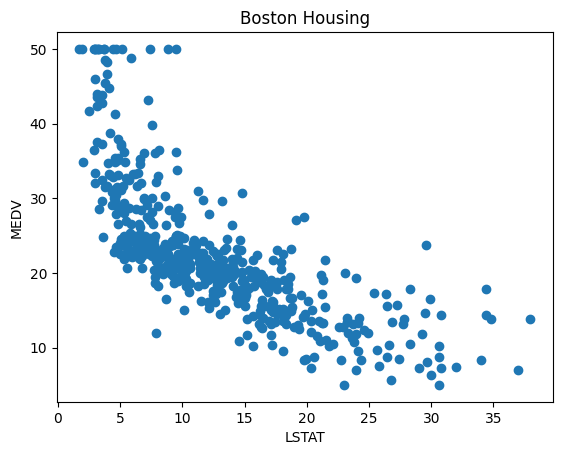

In [96]:
plt.scatter(X, y)
plt.xlabel('LSTAT')
plt.ylabel('MEDV')
plt.title('Boston Housing')
plt.show()

In [97]:
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Thu, 15 May 2025   Prob (F-statistic):           5.08e-88
Time:                        11:17:04   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.5538      0.563     61.415      0.0

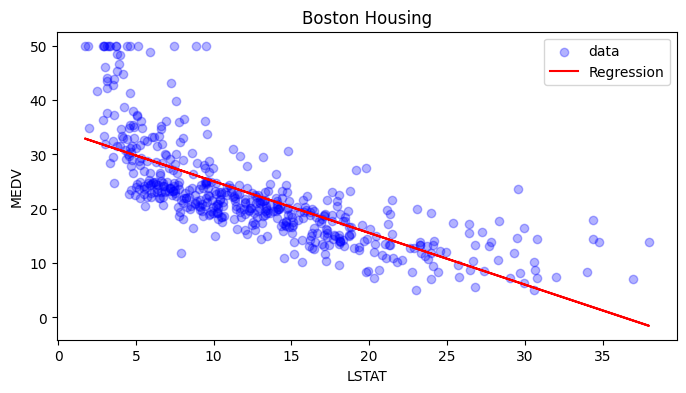

In [98]:
y_pred = model.predict(X_sm)
plt.figure(figsize=(8, 4))
plt.scatter(X, y, color='b', alpha=0.3, label='data')
plt.plot(X, y_pred, color='r', label='Regression')
plt.xlabel('LSTAT')
plt.ylabel('MEDV')
plt.title('Boston Housing')
plt.legend()
plt.show()

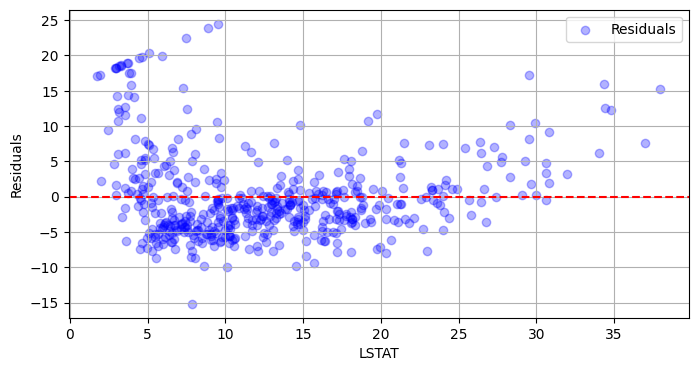

In [99]:
resi = y-y_pred

plt.figure(figsize=(8, 4))
plt.scatter(x=X, y=resi, label='Residuals', color='b', alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("LSTAT")
plt.ylabel("Residuals")
plt.grid(True)
plt.legend()
plt.show()


In [100]:
from sklearn.linear_model import LinearRegression

In [101]:
X = np.array(data['lstat']).reshape(-1, 1)
y = np.array(data['medv'])
log_y = np.log(y)
lr = LinearRegression()
model = lr.fit(X, log_y)
beta_0 = model.intercept_
gamma_0 = np.exp(beta_0)
beta_1 = model.coef_[0]
gamma_1 = beta_1
X_fit = np.linspace(min(X), max(X), 300).reshape(-1, 1)
y_fit = gamma_0*(np.exp(gamma_1*X_fit))

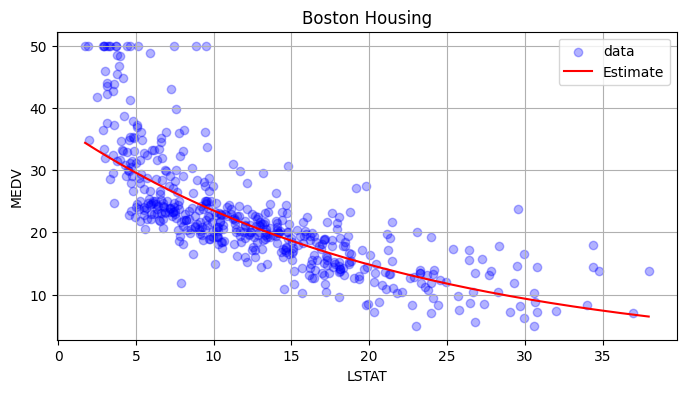

In [102]:
plt.figure(figsize=(8, 4))
plt.scatter(X, y, color='blue', label='data', alpha=0.3)
plt.plot(X_fit, y_fit, color='red', label='Estimate')
plt.xlabel('LSTAT')
plt.ylabel('MEDV')
plt.title('Boston Housing')
plt.legend()
plt.grid(True)
plt.show()

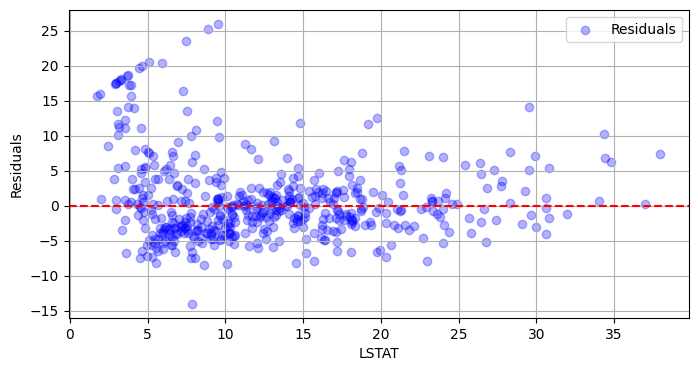

In [103]:
resi = y-gamma_0*np.exp(gamma_1*np.array(data['lstat']))

plt.figure(figsize=(8, 4))
plt.scatter(x=np.array(data['lstat']), y=resi , label='Residuals', color='b', alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("LSTAT")
plt.ylabel("Residuals")
plt.grid(True)
plt.legend()
plt.show()
